CUDA Available: True
CUDA Device Count: 1
Current Device: 0
Device Name: NVIDIA GeForce GTX 1650
Epoch [100/500], MSE: 21117.5549, Validation Loss: 30182.9157
Epoch [200/500], MSE: 12178.1292, Validation Loss: 35365.5914
Epoch [300/500], MSE: 7686.4707, Validation Loss: 12834.0864
Epoch [400/500], MSE: 6179.3203, Validation Loss: 13454.2739
Epoch [500/500], MSE: 5193.0880, Validation Loss: 16865.8085

Total Training Time: 61.45 seconds
Final Training Loss: 5193.0880
Mean Test Loss: 16865.8085
R-squared value: 0.9687


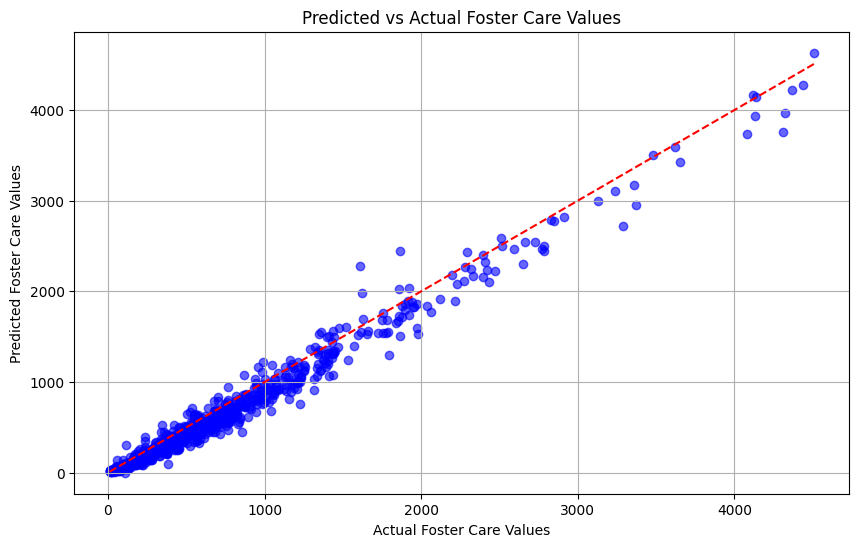

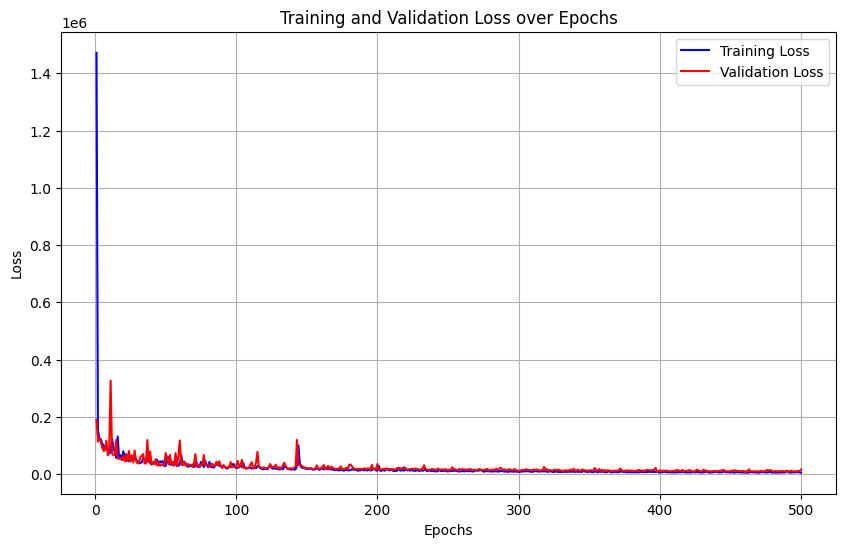

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# Check for CUDA availability
print("CUDA Available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("CUDA Device Count:", torch.cuda.device_count())
    print("Current Device:", torch.cuda.current_device())
    print("Device Name:", torch.cuda.get_device_name(0))

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load data
def load_data(file_path):
    try:
        return pd.read_csv(file_path)
    except FileNotFoundError:
        print(f"File not found: {file_path}")
        exit()

# Specify the path to your CSV file (update with the actual path on your desktop)
file_path = r'C:\\Users\\HP\\Desktop\\MLFinalData.csv'
df = load_data(file_path)

# Define feature columns and target column
feature_columns = [
    'fileyear', 'Program', 'District', 'MedianAnnualFamilyIncome', 'Person', 'IHSS', 
    'Child Welfare', 'DDS', 'Black', 'White', 'Hispanic', 'Asian_PI', 
    'Native_American', 'Other_missing', 'Female', 'Male'
]
target_column = 'Foster Care'

# Check for missing values
def handle_missing_values(data):
    if data.isnull().sum().sum() > 0:
        print("Handling missing values by filling with mean...")
        return data.fillna(data.mean())
    return data

df = handle_missing_values(df)

# Convert data to PyTorch tensors
X = torch.tensor(df[feature_columns].values, dtype=torch.float32)
y = torch.tensor(df[target_column].values, dtype=torch.float32).unsqueeze(1)

# Split into train and test sets
train_size = int(0.8 * len(X))
test_size = len(X) - train_size

dataset = TensorDataset(X, y)
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])

train_loader = DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=64, shuffle=False)

# Define the CNN model
class RegressionCNN(nn.Module):
    def __init__(self):
        super(RegressionCNN, self).__init__()
        self.fc1 = nn.Linear(len(feature_columns), 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# Initialize model, loss, and optimizer
model = RegressionCNN().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop
num_epochs = 500
train_losses = []
val_losses = []  # List to store validation losses
start_time = time.time()

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for features, targets in train_loader:
        features, targets = features.to(device), targets.to(device)

        # Forward pass
        outputs = model(features)
        loss = criterion(outputs, targets)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)
    
    # Validation loss
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for features, targets in test_loader:
            features, targets = features.to(device), targets.to(device)
            outputs = model(features)
            loss = criterion(outputs, targets)
            val_loss += loss.item()

    epoch_val_loss = val_loss / len(test_loader)
    val_losses.append(epoch_val_loss)
    
    # Print MSE every 100 epochs
    if (epoch + 1) % 100 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], MSE: {epoch_train_loss:.4f}, Validation Loss: {epoch_val_loss:.4f}")

# Evaluate the model
model.eval()
test_losses = []
actual_values = []
predicted_values = []

with torch.no_grad():
    for features, targets in test_loader:
        features, targets = features.to(device), targets.to(device)
        outputs = model(features)
        loss = criterion(outputs, targets)
        test_losses.append(loss.item())

        # Collect actual and predicted values for plotting
        actual_values.extend(targets.cpu().numpy())
        predicted_values.extend(outputs.cpu().numpy())

mean_test_loss = np.mean(test_losses)
end_time = time.time()
total_training_time = end_time - start_time

print(f"\nTotal Training Time: {total_training_time:.2f} seconds")
print(f"Final Training Loss: {train_losses[-1]:.4f}")
print(f"Mean Test Loss: {mean_test_loss:.4f}")

# Convert lists to numpy arrays
actual_values = np.array(actual_values)
predicted_values = np.array(predicted_values)

# Calculate R-squared value
r_squared = r2_score(actual_values, predicted_values)
print(f"R-squared value: {r_squared:.4f}")

# Plotting the actual vs predicted values
plt.figure(figsize=(10,6))
plt.scatter(actual_values, predicted_values, color='blue', alpha=0.6)
plt.plot([min(actual_values), max(actual_values)], [min(actual_values), max(actual_values)], color='red', linestyle='--')
plt.title('Predicted vs Actual Foster Care Values')
plt.xlabel('Actual Foster Care Values')
plt.ylabel('Predicted Foster Care Values')
plt.grid(True)
plt.show()

# Plot Training and Validation Loss over Epochs
plt.figure(figsize=(10,6))
plt.plot(range(1, num_epochs + 1), train_losses, label='Training Loss', color='blue')
plt.plot(range(1, num_epochs + 1), val_losses, label='Validation Loss', color='red')
plt.title('Training and Validation Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


CUDA Available: True
CUDA Device Count: 1
Current Device: 0
Device Name: NVIDIA GeForce GTX 1650
Epoch [100/500], MSE: 32368.9650, Validation Loss: 31345.0650
Epoch [200/500], MSE: 15485.4459, Validation Loss: 15481.6216
Epoch [300/500], MSE: 5655.3164, Validation Loss: 9573.1029
Epoch [400/500], MSE: 5436.3561, Validation Loss: 9123.4195
Epoch [500/500], MSE: 1876.4355, Validation Loss: 7848.2324

Total Training Time: 164.32 seconds
Final Training Loss: 1876.4355
Mean Test Loss: 7848.2324
R-squared value: 0.9870


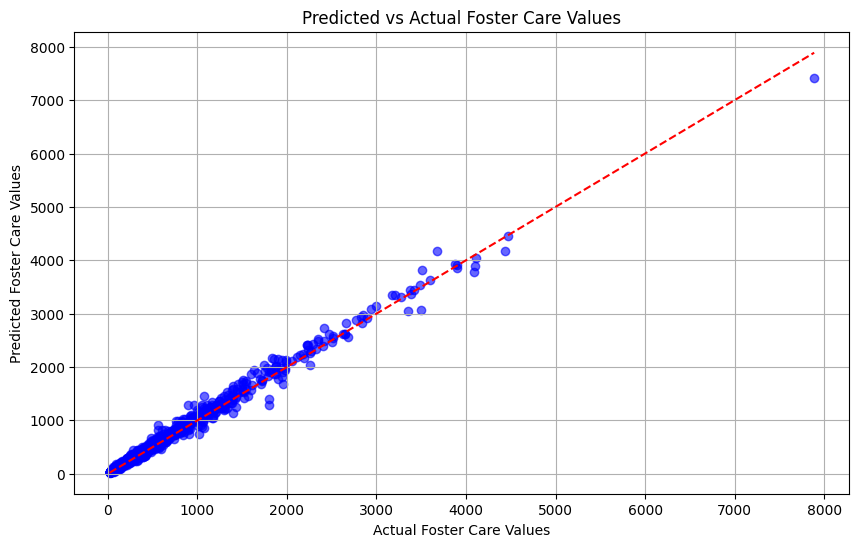

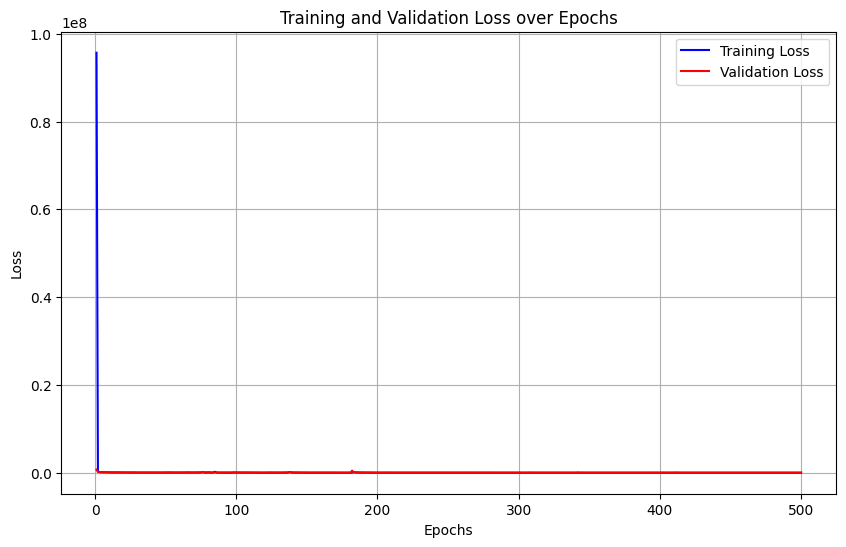

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# Check for CUDA availability
print("CUDA Available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("CUDA Device Count:", torch.cuda.device_count())
    print("Current Device:", torch.cuda.current_device())
    print("Device Name:", torch.cuda.get_device_name(0))

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load data
def load_data(file_path):
    try:
        return pd.read_csv(file_path)
    except FileNotFoundError:
        print(f"File not found: {file_path}")
        exit()

# Specify the path to your CSV file (update with the actual path on your desktop)
file_path = r'C:\\Users\\HP\\Desktop\\MLFinalData.csv'
df = load_data(file_path)

# Define feature columns and target column
feature_columns = [
    'fileyear', 'Program', 'District', 'MedianAnnualFamilyIncome', 'Person', 'IHSS', 
    'Child Welfare', 'DDS', 'Black', 'White', 'Hispanic', 'Asian_PI', 
    'Native_American', 'Other_missing', 'Female', 'Male'
]
target_column = 'Foster Care'

# Check for missing values
def handle_missing_values(data):
    if data.isnull().sum().sum() > 0:
        print("Handling missing values by filling with mean...")
        return data.fillna(data.mean())
    return data

df = handle_missing_values(df)

# Convert data to PyTorch tensors
X = torch.tensor(df[feature_columns].values, dtype=torch.float32)
y = torch.tensor(df[target_column].values, dtype=torch.float32).unsqueeze(1)

# Split into train and test sets
train_size = int(0.8 * len(X))
test_size = len(X) - train_size

dataset = TensorDataset(X, y)
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])

train_loader = DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=64, shuffle=False)

# Define ResNet Block
class ResNetBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(ResNetBlock, self).__init__()
        self.fc1 = nn.Linear(in_channels, out_channels)
        self.fc2 = nn.Linear(out_channels, out_channels)
        self.relu = nn.ReLU()

    def forward(self, x):
        identity = x
        out = self.relu(self.fc1(x))
        out = self.fc2(out)
        out += identity  # Skip connection
        out = self.relu(out)
        return out

# Define the ResNet Model with 10 blocks
class ResNetModel(nn.Module):
    def __init__(self, input_size, num_blocks=10, hidden_size=128):
        super(ResNetModel, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.resnet_blocks = nn.ModuleList([ResNetBlock(hidden_size, hidden_size) for _ in range(num_blocks)])
        self.fc2 = nn.Linear(hidden_size, 1)  # Output layer for regression

    def forward(self, x):
        x = self.fc1(x)
        for block in self.resnet_blocks:
            x = block(x)
        x = self.fc2(x)
        return x

# Initialize model, loss, and optimizer
model = ResNetModel(input_size=len(feature_columns)).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop
num_epochs = 500
train_losses = []
val_losses = []  # List to store validation losses
start_time = time.time()

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for features, targets in train_loader:
        features, targets = features.to(device), targets.to(device)

        # Forward pass
        outputs = model(features)
        loss = criterion(outputs, targets)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)
    
    # Validation loss
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for features, targets in test_loader:
            features, targets = features.to(device), targets.to(device)
            outputs = model(features)
            loss = criterion(outputs, targets)
            val_loss += loss.item()

    epoch_val_loss = val_loss / len(test_loader)
    val_losses.append(epoch_val_loss)
    
    # Print MSE every 100 epochs
    if (epoch + 1) % 100 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], MSE: {epoch_train_loss:.4f}, Validation Loss: {epoch_val_loss:.4f}")

# Evaluate the model
model.eval()
test_losses = []
actual_values = []
predicted_values = []

with torch.no_grad():
    for features, targets in test_loader:
        features, targets = features.to(device), targets.to(device)
        outputs = model(features)
        loss = criterion(outputs, targets)
        test_losses.append(loss.item())

        # Collect actual and predicted values for plotting
        actual_values.extend(targets.cpu().numpy())
        predicted_values.extend(outputs.cpu().numpy())

mean_test_loss = np.mean(test_losses)
end_time = time.time()
total_training_time = end_time - start_time

print(f"\nTotal Training Time: {total_training_time:.2f} seconds")
print(f"Final Training Loss: {train_losses[-1]:.4f}")
print(f"Mean Test Loss: {mean_test_loss:.4f}")

# Calculate R-squared value
r_squared = r2_score(actual_values, predicted_values)
print(f"R-squared value: {r_squared:.4f}")

# Convert lists to numpy arrays
actual_values = np.array(actual_values)
predicted_values = np.array(predicted_values)

# Plotting the actual vs predicted values
plt.figure(figsize=(10,6))
plt.scatter(actual_values, predicted_values, color='blue', alpha=0.6)
plt.plot([min(actual_values), max(actual_values)], [min(actual_values), max(actual_values)], color='red', linestyle='--')
plt.title('Predicted vs Actual Foster Care Values')
plt.xlabel('Actual Foster Care Values')
plt.ylabel('Predicted Foster Care Values')
plt.grid(True)
plt.show()

# Plot Training and Validation Loss over Epochs
plt.figure(figsize=(10,6))
plt.plot(range(1, num_epochs + 1), train_losses, label='Training Loss', color='blue')
plt.plot(range(1, num_epochs + 1), val_losses, label='Validation Loss', color='red')
plt.title('Training and Validation Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


In [17]:
# Exclude the feature "Child Welfare" from analysis
excluded_feature = "Child Welfare"

# Identify indices of features to include
included_indices = [i for i, feature in enumerate(feature_columns) if feature != excluded_feature]
included_features = [feature for feature in feature_columns if feature != excluded_feature]

# Extract weights of the first layer for included features
fc1_weights = model.fc1.weight.detach().cpu().numpy()
fc1_weights_included = fc1_weights[:, included_indices]

# Compute importance as the average absolute weight across all hidden units
feature_importance = np.mean(np.abs(fc1_weights_included), axis=0)

# Compute the average sign (direction) of the weights for each feature
feature_direction = np.mean(np.sign(fc1_weights_included), axis=0)

# Map to feature names with importance and direction
feature_importance_dict = {
    included_features[i]: (feature_importance[i], feature_direction[i])
    for i in range(len(included_features))
}

# Sort by absolute importance
sorted_features = sorted(
    feature_importance_dict.items(),
    key=lambda x: x[1][0],  # Sort by importance
    reverse=True
)

# Display the results
print(f"Feature Importance and Direction (excluding '{excluded_feature}'):")
for feature, (importance, direction) in sorted_features:
    direction_label = "positive" if direction > 0 else "negative"
    print(f"{feature}: {importance:.4f} ({direction_label})")


Feature Importance and Direction (excluding 'Child Welfare'):
Program: 1.3860 (negative)
District: 0.6797 (positive)
Native_American: 0.4273 (negative)
DDS: 0.3490 (negative)
IHSS: 0.3139 (negative)
fileyear: 0.2602 (negative)
Black: 0.2116 (positive)
Asian_PI: 0.2030 (negative)
Other_missing: 0.1923 (negative)
White: 0.1638 (positive)
Male: 0.1490 (negative)
Hispanic: 0.1317 (negative)
Female: 0.1285 (positive)
Person: 0.1091 (negative)
MedianAnnualFamilyIncome: 0.0912 (positive)


CUDA Available: True
CUDA Device Count: 1
Current Device: 0
Device Name: NVIDIA GeForce GTX 1650
Epoch [100/500], MSE: 57265.6471, Validation Loss: 26281.9292
Epoch [200/500], MSE: 43567.1653, Validation Loss: 48112.1429
Epoch [300/500], MSE: 23363.3388, Validation Loss: 27459.9217
Epoch [400/500], MSE: 25769.8965, Validation Loss: 19282.3745
Epoch [500/500], MSE: 23383.4289, Validation Loss: 34850.9403

Total Training Time: 73.41 seconds
Final Training Loss: 23383.4289
Mean Test Loss: 34850.9403
R-squared value: 0.9477


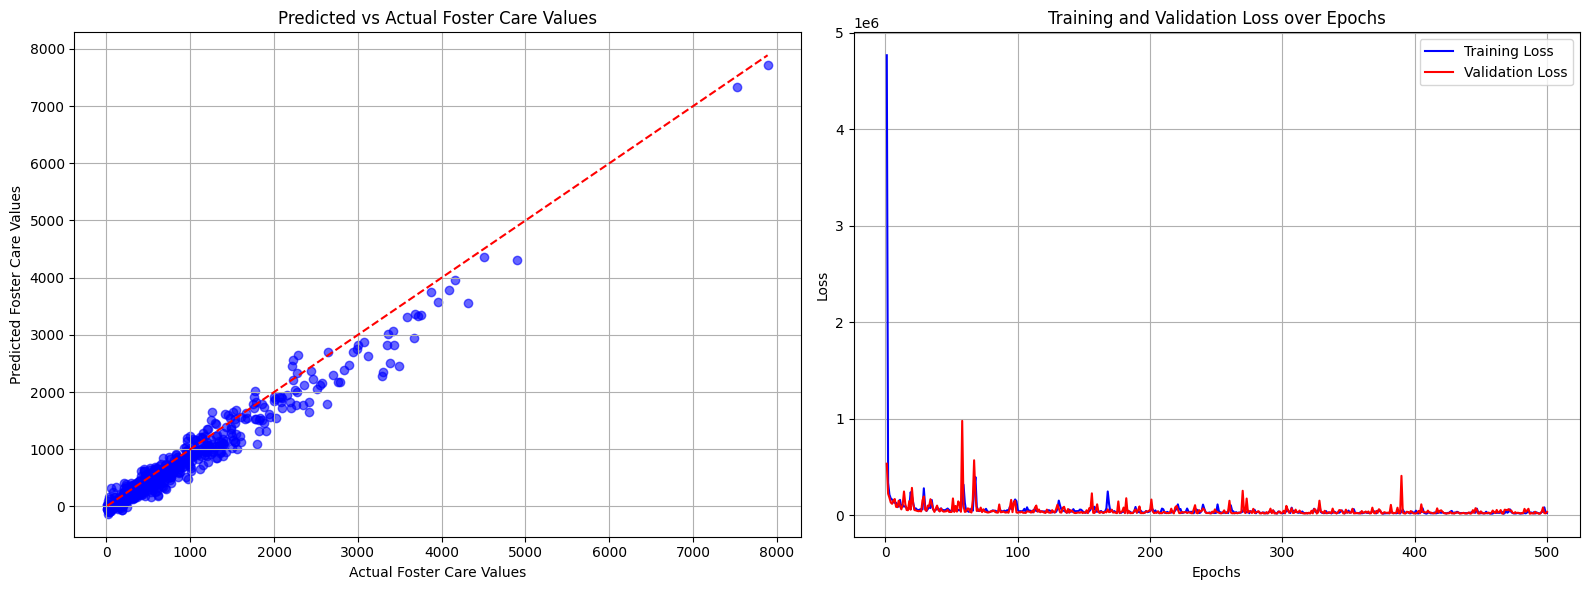

In [20]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# Check for CUDA availability
print("CUDA Available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("CUDA Device Count:", torch.cuda.device_count())
    print("Current Device:", torch.cuda.current_device())
    print("Device Name:", torch.cuda.get_device_name(0))

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load data
def load_data(file_path):
    try:
        return pd.read_csv(file_path)
    except FileNotFoundError:
        print(f"File not found: {file_path}")
        exit()

# Specify the path to your CSV file
file_path = r'C:\\Users\\HP\\Desktop\\MLFinalData.csv'
df = load_data(file_path)

# Define feature columns and target column
feature_columns = [
    'fileyear', 'Program', 'District', 'MedianAnnualFamilyIncome', 'Person', 'IHSS',
    'Child Welfare', 'DDS', 'Black', 'White', 'Hispanic', 'Asian_PI',
    'Native_American', 'Other_missing', 'Female', 'Male'
]
target_column = 'Foster Care'

# Check for missing values
def handle_missing_values(data):
    if data.isnull().sum().sum() > 0:
        print("Handling missing values by filling with mean...")
        return data.fillna(data.mean())
    return data

df = handle_missing_values(df)

# Convert data to PyTorch tensors
X = torch.tensor(df[feature_columns].values, dtype=torch.float32)
y = torch.tensor(df[target_column].values, dtype=torch.float32).unsqueeze(1)

# Split into train and test sets
train_size = int(0.8 * len(X))
test_size = len(X) - train_size

dataset = TensorDataset(X, y)
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])

train_loader = DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=64, shuffle=False)

# Define the FCNN model with 1 hidden layer of 128 neurons
class FullyConnectedNN(nn.Module):
    def __init__(self, input_size, hidden_size=128):
        super(FullyConnectedNN, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, 1)

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Initialize the model, loss function, and optimizer
model = FullyConnectedNN(input_size=len(feature_columns)).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop
num_epochs = 500
train_losses = []
val_losses = []
start_time = time.time()

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for features, targets in train_loader:
        features, targets = features.to(device), targets.to(device)

        # Forward pass
        outputs = model(features)
        loss = criterion(outputs, targets)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)
    
    # Validation loss
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for features, targets in test_loader:
            features, targets = features.to(device), targets.to(device)
            outputs = model(features)
            loss = criterion(outputs, targets)
            val_loss += loss.item()

    epoch_val_loss = val_loss / len(test_loader)
    val_losses.append(epoch_val_loss)
    
    # Print MSE every 100 epochs
    if (epoch + 1) % 100 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], MSE: {epoch_train_loss:.4f}, Validation Loss: {epoch_val_loss:.4f}")

# Evaluate the model
model.eval()
test_losses = []
actual_values = []
predicted_values = []

with torch.no_grad():
    for features, targets in test_loader:
        features, targets = features.to(device), targets.to(device)
        outputs = model(features)
        loss = criterion(outputs, targets)
        test_losses.append(loss.item())

        # Collect actual and predicted values for plotting
        actual_values.extend(targets.cpu().numpy())
        predicted_values.extend(outputs.cpu().numpy())

mean_test_loss = np.mean(test_losses)
end_time = time.time()
total_training_time = end_time - start_time

print(f"\nTotal Training Time: {total_training_time:.2f} seconds")
print(f"Final Training Loss: {train_losses[-1]:.4f}")
print(f"Mean Test Loss: {mean_test_loss:.4f}")

# Calculate R-squared value
r_squared = r2_score(actual_values, predicted_values)
print(f"R-squared value: {r_squared:.4f}")

# Plotting Predicted vs Actual and Training/Validation Loss
actual_values = np.array(actual_values)
predicted_values = np.array(predicted_values)

# Create a figure with two subplots
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

# Plot Predicted vs Actual Foster Care Values
axs[0].scatter(actual_values, predicted_values, color='blue', alpha=0.6)
axs[0].plot([min(actual_values), max(actual_values)], [min(actual_values), max(actual_values)], color='red', linestyle='--')
axs[0].set_title('Predicted vs Actual Foster Care Values')
axs[0].set_xlabel('Actual Foster Care Values')
axs[0].set_ylabel('Predicted Foster Care Values')
axs[0].grid(True)

# Plot Training and Validation Loss over Epochs
axs[1].plot(range(1, num_epochs + 1), train_losses, label='Training Loss', color='blue')
axs[1].plot(range(1, num_epochs + 1), val_losses, label='Validation Loss', color='red')
axs[1].set_title('Training and Validation Loss over Epochs')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Loss')
axs[1].legend()
axs[1].grid(True)

# Adjust layout and show the plots
plt.tight_layout()
plt.show()


CUDA Available: True
CUDA Device Count: 1
Current Device: 0
Device Name: NVIDIA GeForce GTX 1650
Epoch [100/500], MSE: 24417.7191, Validation Loss: 35528.2408
Epoch [200/500], MSE: 13344.9416, Validation Loss: 16493.9915
Epoch [300/500], MSE: 8724.4814, Validation Loss: 10249.4278
Epoch [400/500], MSE: 7467.9993, Validation Loss: 9862.3835
Epoch [500/500], MSE: 4990.6301, Validation Loss: 10236.1297

Total Training Time: 82.27 seconds
Final Training Loss: 4990.6301
Mean Test Loss: 10236.1297
R-squared value: 0.9819


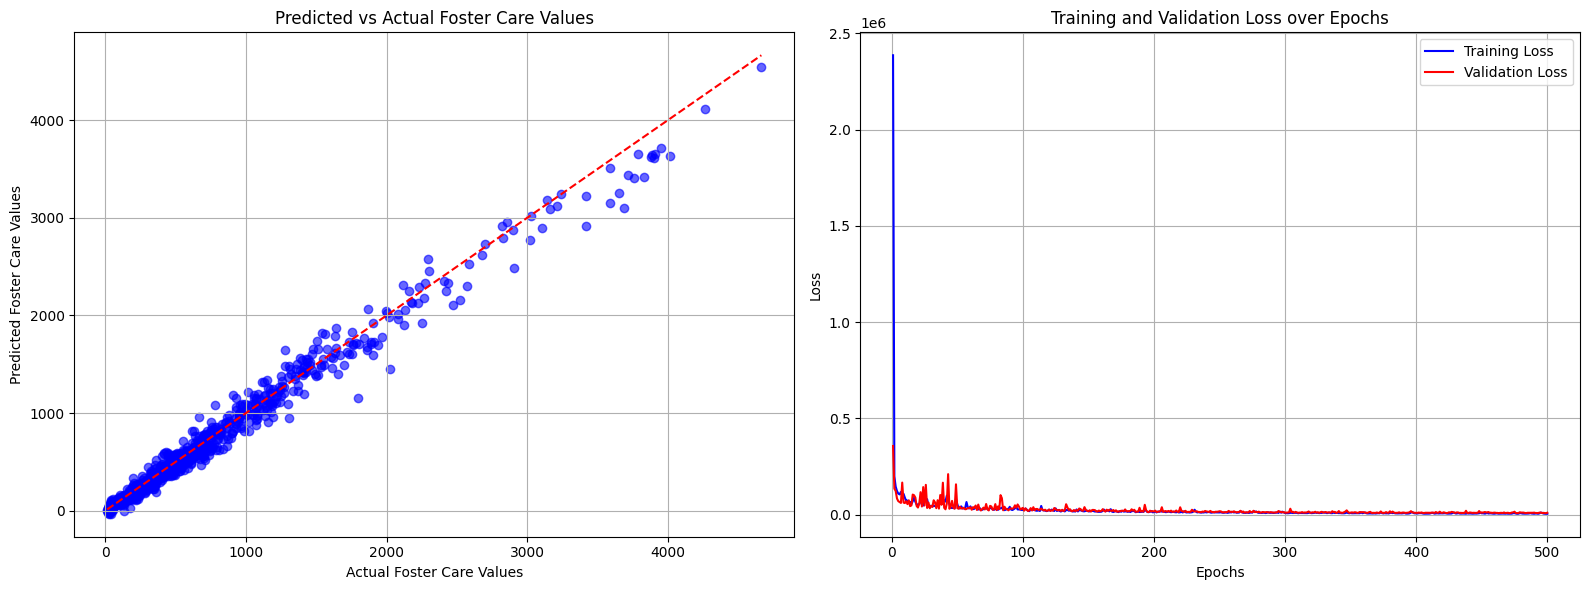

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# Check for CUDA availability
print("CUDA Available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("CUDA Device Count:", torch.cuda.device_count())
    print("Current Device:", torch.cuda.current_device())
    print("Device Name:", torch.cuda.get_device_name(0))

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load data
def load_data(file_path):
    try:
        return pd.read_csv(file_path)
    except FileNotFoundError:
        print(f"File not found: {file_path}")
        exit()

# Specify the path to your CSV file
file_path = r'C:\\Users\\HP\\Desktop\\MLFinalData.csv'
df = load_data(file_path)

# Define feature columns and target column
feature_columns = [
    'fileyear', 'Program', 'District', 'MedianAnnualFamilyIncome', 'Person', 'IHSS',
    'Child Welfare', 'DDS', 'Black', 'White', 'Hispanic', 'Asian_PI',
    'Native_American', 'Other_missing', 'Female', 'Male'
]
target_column = 'Foster Care'

# Check for missing values
def handle_missing_values(data):
    if data.isnull().sum().sum() > 0:
        print("Handling missing values by filling with mean...")
        return data.fillna(data.mean())
    return data

df = handle_missing_values(df)

# Convert data to PyTorch tensors
X = torch.tensor(df[feature_columns].values, dtype=torch.float32)
y = torch.tensor(df[target_column].values, dtype=torch.float32).unsqueeze(1)

# Split into train and test sets
train_size = int(0.8 * len(X))
test_size = len(X) - train_size

dataset = TensorDataset(X, y)
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])

train_loader = DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=64, shuffle=False)

# Define the FCNN model with 2 hidden layers of 128 neurons and 64 neurons
class FullyConnectedNN(nn.Module):
    def __init__(self, input_size, hidden_size=128):
        super(FullyConnectedNN, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, 64)
        self.relu = nn.ReLU()
        self.fc3 = nn.Linear(64, 1)

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# Initialize the model, loss function, and optimizer
model = FullyConnectedNN(input_size=len(feature_columns)).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop
num_epochs = 500
train_losses = []
val_losses = []
start_time = time.time()

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for features, targets in train_loader:
        features, targets = features.to(device), targets.to(device)

        # Forward pass
        outputs = model(features)
        loss = criterion(outputs, targets)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)
    
    # Validation loss
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for features, targets in test_loader:
            features, targets = features.to(device), targets.to(device)
            outputs = model(features)
            loss = criterion(outputs, targets)
            val_loss += loss.item()

    epoch_val_loss = val_loss / len(test_loader)
    val_losses.append(epoch_val_loss)
    
    # Print MSE every 100 epochs
    if (epoch + 1) % 100 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], MSE: {epoch_train_loss:.4f}, Validation Loss: {epoch_val_loss:.4f}")

# Evaluate the model
model.eval()
test_losses = []
actual_values = []
predicted_values = []

with torch.no_grad():
    for features, targets in test_loader:
        features, targets = features.to(device), targets.to(device)
        outputs = model(features)
        loss = criterion(outputs, targets)
        test_losses.append(loss.item())

        # Collect actual and predicted values for plotting
        actual_values.extend(targets.cpu().numpy())
        predicted_values.extend(outputs.cpu().numpy())

mean_test_loss = np.mean(test_losses)
end_time = time.time()
total_training_time = end_time - start_time

print(f"\nTotal Training Time: {total_training_time:.2f} seconds")
print(f"Final Training Loss: {train_losses[-1]:.4f}")
print(f"Mean Test Loss: {mean_test_loss:.4f}")

# Calculate R-squared value
r_squared = r2_score(actual_values, predicted_values)
print(f"R-squared value: {r_squared:.4f}")

# Plotting Predicted vs Actual and Training/Validation Loss
actual_values = np.array(actual_values)
predicted_values = np.array(predicted_values)

# Create a figure with two subplots
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

# Plot Predicted vs Actual Foster Care Values
axs[0].scatter(actual_values, predicted_values, color='blue', alpha=0.6)
axs[0].plot([min(actual_values), max(actual_values)], [min(actual_values), max(actual_values)], color='red', linestyle='--')
axs[0].set_title('Predicted vs Actual Foster Care Values')
axs[0].set_xlabel('Actual Foster Care Values')
axs[0].set_ylabel('Predicted Foster Care Values')
axs[0].grid(True)

# Plot Training and Validation Loss over Epochs
axs[1].plot(range(1, num_epochs + 1), train_losses, label='Training Loss', color='blue')
axs[1].plot(range(1, num_epochs + 1), val_losses, label='Validation Loss', color='red')
axs[1].set_title('Training and Validation Loss over Epochs')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Loss')
axs[1].legend()
axs[1].grid(True)

# Adjust layout and show the plots
plt.tight_layout()
plt.show()


CUDA Available: True
CUDA Device Count: 1
Current Device: 0
Device Name: NVIDIA GeForce GTX 1650
Epoch [100/500], MSE: 18575.1273, Validation Loss: 40968.6586
Epoch [200/500], MSE: 8861.1080, Validation Loss: 11838.0112
Epoch [300/500], MSE: 5944.6611, Validation Loss: 9146.4813
Epoch [400/500], MSE: 4717.5953, Validation Loss: 8446.9477
Epoch [500/500], MSE: 3431.4667, Validation Loss: 7554.2095

Total Training Time: 92.47 seconds
Final Training Loss: 3431.4667
Mean Test Loss: 7554.2095
R-squared value: 0.9867


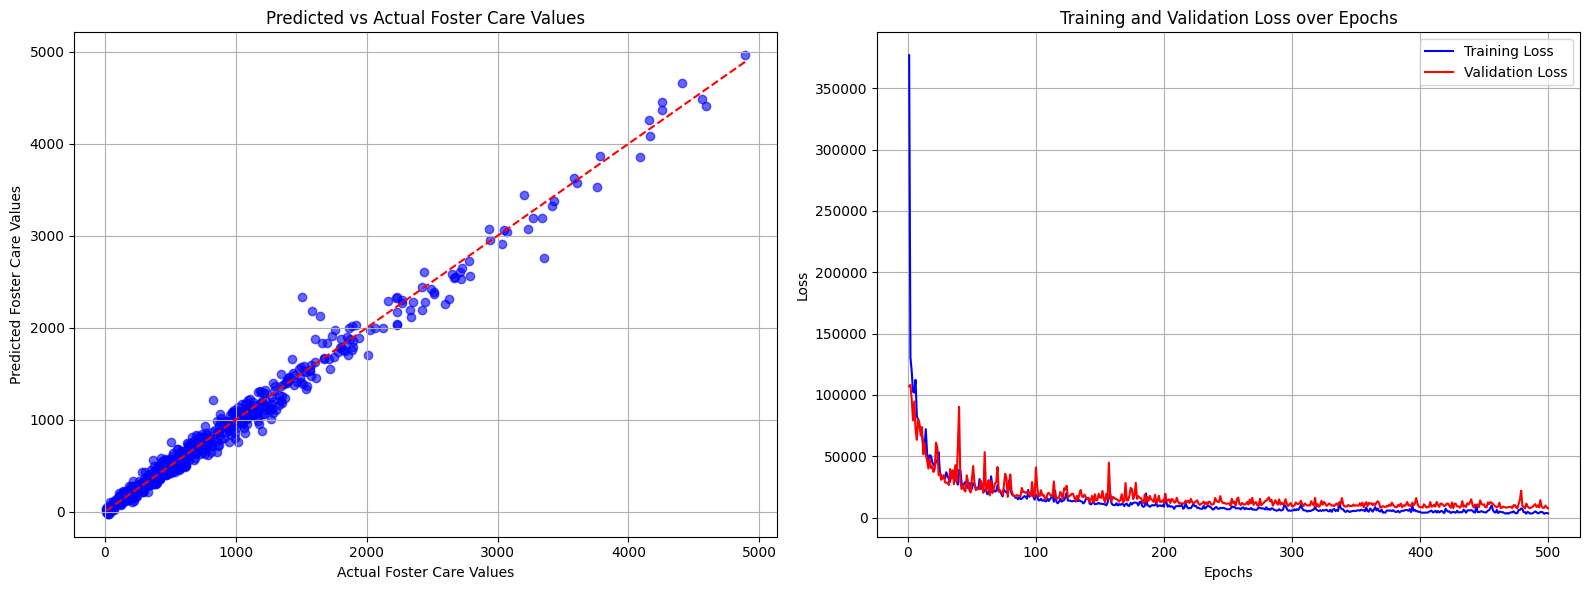

In [21]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# Check for CUDA availability
print("CUDA Available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("CUDA Device Count:", torch.cuda.device_count())
    print("Current Device:", torch.cuda.current_device())
    print("Device Name:", torch.cuda.get_device_name(0))

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load data
def load_data(file_path):
    try:
        return pd.read_csv(file_path)
    except FileNotFoundError:
        print(f"File not found: {file_path}")
        exit()

# Specify the path to your CSV file
file_path = r'C:\\Users\\HP\\Desktop\\MLFinalData.csv'
df = load_data(file_path)

# Define feature columns and target column
feature_columns = [
    'fileyear', 'Program', 'District', 'MedianAnnualFamilyIncome', 'Person', 'IHSS',
    'Child Welfare', 'DDS', 'Black', 'White', 'Hispanic', 'Asian_PI',
    'Native_American', 'Other_missing', 'Female', 'Male'
]
target_column = 'Foster Care'

# Check for missing values
def handle_missing_values(data):
    if data.isnull().sum().sum() > 0:
        print("Handling missing values by filling with mean...")
        return data.fillna(data.mean())
    return data

df = handle_missing_values(df)

# Convert data to PyTorch tensors
X = torch.tensor(df[feature_columns].values, dtype=torch.float32)
y = torch.tensor(df[target_column].values, dtype=torch.float32).unsqueeze(1)

# Split into train and test sets
train_size = int(0.8 * len(X))
test_size = len(X) - train_size

dataset = TensorDataset(X, y)
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])

train_loader = DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=64, shuffle=False)

# Define the FCNN model with 3 hidden layers of 128 neurons, 64 neurons, and 32 neurons
class FullyConnectedNN(nn.Module):
    def __init__(self, input_size, hidden_size=128):
        super(FullyConnectedNN, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, 64)
        self.relu = nn.ReLU()
        self.fc3 = nn.Linear(64, 32)
        self.relu = nn.ReLU()
        self.fc4 = nn.Linear(32, 1)

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))
        x = self.fc4(x)
        return x

# Initialize the model, loss function, and optimizer
model = FullyConnectedNN(input_size=len(feature_columns)).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop
num_epochs = 500
train_losses = []
val_losses = []
start_time = time.time()

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for features, targets in train_loader:
        features, targets = features.to(device), targets.to(device)

        # Forward pass
        outputs = model(features)
        loss = criterion(outputs, targets)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)
    
    # Validation loss
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for features, targets in test_loader:
            features, targets = features.to(device), targets.to(device)
            outputs = model(features)
            loss = criterion(outputs, targets)
            val_loss += loss.item()

    epoch_val_loss = val_loss / len(test_loader)
    val_losses.append(epoch_val_loss)
    
    # Print MSE every 100 epochs
    if (epoch + 1) % 100 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], MSE: {epoch_train_loss:.4f}, Validation Loss: {epoch_val_loss:.4f}")

# Evaluate the model
model.eval()
test_losses = []
actual_values = []
predicted_values = []

with torch.no_grad():
    for features, targets in test_loader:
        features, targets = features.to(device), targets.to(device)
        outputs = model(features)
        loss = criterion(outputs, targets)
        test_losses.append(loss.item())

        # Collect actual and predicted values for plotting
        actual_values.extend(targets.cpu().numpy())
        predicted_values.extend(outputs.cpu().numpy())

mean_test_loss = np.mean(test_losses)
end_time = time.time()
total_training_time = end_time - start_time

print(f"\nTotal Training Time: {total_training_time:.2f} seconds")
print(f"Final Training Loss: {train_losses[-1]:.4f}")
print(f"Mean Test Loss: {mean_test_loss:.4f}")

# Calculate R-squared value
r_squared = r2_score(actual_values, predicted_values)
print(f"R-squared value: {r_squared:.4f}")

# Plotting Predicted vs Actual and Training/Validation Loss
actual_values = np.array(actual_values)
predicted_values = np.array(predicted_values)

# Create a figure with two subplots
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

# Plot Predicted vs Actual Foster Care Values
axs[0].scatter(actual_values, predicted_values, color='blue', alpha=0.6)
axs[0].plot([min(actual_values), max(actual_values)], [min(actual_values), max(actual_values)], color='red', linestyle='--')
axs[0].set_title('Predicted vs Actual Foster Care Values')
axs[0].set_xlabel('Actual Foster Care Values')
axs[0].set_ylabel('Predicted Foster Care Values')
axs[0].grid(True)

# Plot Training and Validation Loss over Epochs
axs[1].plot(range(1, num_epochs + 1), train_losses, label='Training Loss', color='blue')
axs[1].plot(range(1, num_epochs + 1), val_losses, label='Validation Loss', color='red')
axs[1].set_title('Training and Validation Loss over Epochs')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Loss')
axs[1].legend()
axs[1].grid(True)

# Adjust layout and show the plots
plt.tight_layout()
plt.show()
